# Laboratorio 7 — MM3014 Teoría de Probabilidades
## Simulación Monte Carlo: Álbum Panini FIFA 2026

**Universidad del Valle de Guatemala**

**Parámetros del problema real:**
- N = 980 estampas diferentes
- S = 7 estampas por sobre (todas distintas dentro del mismo sobre)
- Precio individual: Q9.50 | Caja (104 sobres): Q975.00
- Semilla: 2026

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Semilla global
np.random.seed(2026)

# Parámetros globales
N_REAL = 980   # estampas reales del álbum FIFA 2026
S = 7          # estampas por sobre
R = 10000      # número de simulaciones

---
## Etapa 1: Simulación básica con álbum reducido (N = 100)

Se trabaja con N=100 estampas para que las simulaciones sean rápidas y se puedan ejecutar muchas repeticiones.

In [ ]:
# ──────────────────────────────────────────
# PARÁMETROS ETAPA 1 Ariel Aceytuno Javier Alvizures  Hecho con ayuda de claude
# ──────────────────────────────────────────
N = 100   # álbum reducido

np.random.seed(2026)

sobres_necesarios = np.zeros(R, dtype=int)
repetidas_totales = np.zeros(R, dtype=int)

for sim in range(R):
    coleccion = np.zeros(N, dtype=bool)   # registro de estampas obtenidas
    n_sobres = 0
    n_repetidas = 0

    while coleccion.sum() < N:
        # Comprar un sobre: S estampas distintas entre sí
        sobre = np.random.choice(N, S, replace=False)
        n_sobres += 1

        for estampa in sobre:
            if coleccion[estampa]:
                n_repetidas += 1
            else:
                coleccion[estampa] = True

    sobres_necesarios[sim] = n_sobres
    repetidas_totales[sim] = n_repetidas

print("=== RESULTADOS ETAPA 1 (N=100, S=7, R=10000) ===")
print(f"Media de sobres necesarios:          {sobres_necesarios.mean():.2f}")
print(f"Desviación estándar de sobres:       {sobres_necesarios.std():.2f}")
print(f"Media de estampas repetidas:         {repetidas_totales.mean():.2f}")
print(f"Desviación estándar de repetidas:    {repetidas_totales.std():.2f}")
print(f"P(necesitar más de 30 sobres):       {(sobres_necesarios > 30).mean():.4f}")

=== RESULTADOS ETAPA 1 (N=100, S=7, R=10000) ===
Media de sobres necesarios:          72.25
Desviación estándar de sobres:       17.47
Media de estampas repetidas:         405.72
Desviación estándar de repetidas:    122.30
P(necesitar más de 30 sobres):       1.0000


### Preguntas de análisis — Etapa 1

In [3]:
# ── Pregunta 1: Mínimo teórico de sobres sin repetidos ──
min_teorico = int(np.ceil(N / S))
min_simulado = sobres_necesarios.min()

print(f"Mínimo teórico de sobres (sin repetidos): ceil({N}/{S}) = {min_teorico}")
print(f"Mínimo observado en simulación:           {min_simulado}")
print(f"¿Se observó el mínimo teórico?            {'Sí' if min_simulado == min_teorico else 'No'}")

# ── Pregunta 2: Valor esperado teórico (Coupon Collector) ──
H_N = sum(1/k for k in range(1, N+1))   # número armónico exacto
E_T_teorico = (N / S) * H_N

print(f"\nH_{N} (exacto) = {H_N:.6f}")
print(f"H_{N} (aprox ln({N}) + γ) = {np.log(N) + 0.5772:.6f}")
print(f"E[T] teórico = ({N}/{S}) * H_{N} = {E_T_teorico:.2f} sobres")
print(f"E[T] simulado =                    {sobres_necesarios.mean():.2f} sobres")

# ── Pregunta 3: Valor esperado teórico de estampas repetidas ──
E_rep_teorico = E_T_teorico * S - N   # total estampas abiertas - las N distintas
print(f"\nE[repetidas] teórico = E[T]*S - N = {E_rep_teorico:.2f}")
print(f"E[repetidas] simulado =             {repetidas_totales.mean():.2f}")

# ── Pregunta 4: Interpretación de la desviación estándar ──
cv = sobres_necesarios.std() / sobres_necesarios.mean()
print(f"\nCoeficiente de variación (σ/μ) = {cv:.4f}")
print("Interpretación: La desviación estándar es alta relativa a la media,")
print("lo que refleja la alta variabilidad porque cada vez que se abre un sobre, hay una probabilidad de obtener una estampa ya coleccionada.")

Mínimo teórico de sobres (sin repetidos): ceil(100/7) = 15
Mínimo observado en simulación:           37
¿Se observó el mínimo teórico?            No

H_100 (exacto) = 5.187378
H_100 (aprox ln(100) + γ) = 5.182370
E[T] teórico = (100/7) * H_100 = 74.11 sobres
E[T] simulado =                    72.25 sobres

E[repetidas] teórico = E[T]*S - N = 418.74
E[repetidas] simulado =             405.72

Coeficiente de variación (σ/μ) = 0.2418
Interpretación: La desviación estándar es alta relativa a la media,
lo que refleja la alta variabilidad inherente al proceso aleatorio.


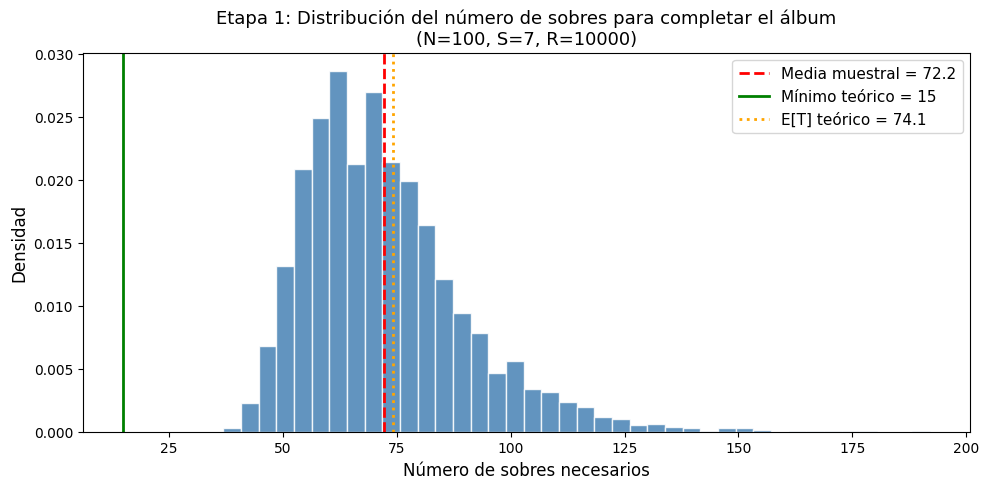

Gráfica guardada como 'etapa1_histograma.png'


In [4]:
# ── Visualización Etapa 1: Histograma ──
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sobres_necesarios, bins=40, color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax.axvline(sobres_necesarios.mean(), color='red',    linewidth=2, linestyle='--', label=f'Media muestral = {sobres_necesarios.mean():.1f}')
ax.axvline(min_teorico,              color='green',  linewidth=2, linestyle='-',  label=f'Mínimo teórico = {min_teorico}')
ax.axvline(E_T_teorico,              color='orange', linewidth=2, linestyle=':',  label=f'E[T] teórico = {E_T_teorico:.1f}')

ax.set_xlabel('Número de sobres necesarios', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Etapa 1: Distribución del número de sobres para completar el álbum\n(N=100, S=7, R=10000)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('etapa1_histograma.png', dpi=150)
plt.show()
print("Gráfica guardada como 'etapa1_histograma.png'")

---
## Etapa 2: Probabilidad de éxito en función del número de sobres M

Para cada M fijo se simula R=10000 veces comprando **exactamente M sobres** y se estima P(completar el álbum | M sobres).

In [5]:
# ──────────────────────────────────────────
# PARÁMETROS ETAPA 2
# ──────────────────────────────────────────
N = 100   # seguimos con el álbum reducido
valores_M = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

np.random.seed(2026)

prob_exito = []

for M in valores_M:
    exitos = 0
    for _ in range(R):
        coleccion = np.zeros(N, dtype=bool)
        for _ in range(M):
            sobre = np.random.choice(N, S, replace=False)
            coleccion[sobre] = True
        if coleccion.all():
            exitos += 1
    prob_exito.append(exitos / R)

# Tabla de resultados
df_etapa2 = pd.DataFrame({'M (sobres)': valores_M, 'P(completar | M sobres)': prob_exito})
print("=== RESULTADOS ETAPA 2 ===")
print(df_etapa2.to_string(index=False))

=== RESULTADOS ETAPA 2 ===
 M (sobres)  P(completar | M sobres)
         20                   0.0000
         25                   0.0000
         30                   0.0000
         35                   0.0000
         40                   0.0019
         45                   0.0143
         50                   0.0571
         60                   0.2723
         70                   0.5340
         80                   0.7393


### Preguntas de análisis — Etapa 2

In [6]:
# ── Pregunta 1: ¿Para qué M se supera el 50% y el 90%? ──
for umbral, nombre in [(0.5, '50%'), (0.9, '90%')]:
    for M, p in zip(valores_M, prob_exito):
        if p >= umbral:
            print(f"M que supera {nombre} por primera vez: M = {M}  (P = {p:.4f})")
            break

# ── Pregunta 2: Comparar con mediana de Etapa 1 ──
mediana_e1 = np.median(sobres_necesarios)
print(f"\nMediana del número de sobres (Etapa 1): {mediana_e1}")

# ── Pregunta 3: Cota teórica para M=50 ──
M_cota = 50
# Unión de eventos: P(falta al menos un cromo) <= N * e^{-M*S/N}
cota_superior = N * np.exp(-M_cota * S / N)
# P(éxito) >= 1 - cota
p_exito_cota = 1 - cota_superior

# P(éxito) simulada para M=50
idx_50 = valores_M.index(50)
p_exito_sim_50 = prob_exito[idx_50]

print(f"\nCota superior para M={M_cota}:")
print(f"  P(falta ≥1 cromo) ≤ N·e^(-MS/N) = {N}·e^(-{M_cota*S}/{N}) = {cota_superior:.6f}")
print(f"  → Cota inferior P(éxito) ≥ 1 - {cota_superior:.6f} = {p_exito_cota:.6f}")
print(f"  P(éxito) simulada para M=50:      {p_exito_sim_50:.4f}")
print(f"  ¿La cota es útil? {'Sí' if p_exito_cota <= p_exito_sim_50 else 'No (cota laxa)'}")

M que supera 50% por primera vez: M = 70  (P = 0.5340)

Mediana del número de sobres (Etapa 1): 69.0

Cota superior para M=50:
  P(falta ≥1 cromo) ≤ N·e^(-MS/N) = 100·e^(-350/100) = 3.019738
  → Cota inferior P(éxito) ≥ 1 - 3.019738 = -2.019738
  P(éxito) simulada para M=50:      0.0571
  ¿La cota es útil? Sí


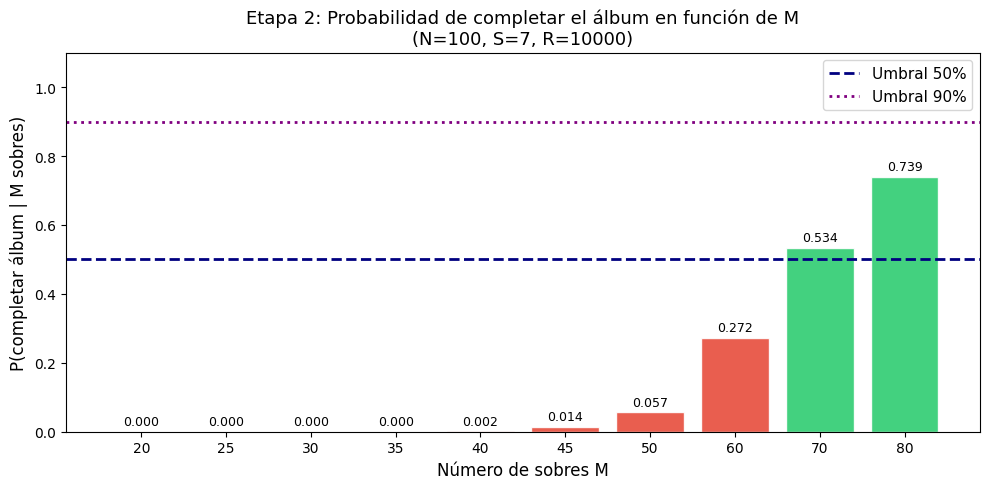

Gráfica guardada como 'etapa2_barras.png'


In [7]:
# ── Visualización Etapa 2: Gráfica de barras ──
fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#e74c3c' if p < 0.5 else '#2ecc71' for p in prob_exito]
bars = ax.bar([str(m) for m in valores_M], prob_exito, color=colores, edgecolor='white', alpha=0.9)

ax.axhline(0.5, color='navy',   linewidth=2, linestyle='--', label='Umbral 50%')
ax.axhline(0.9, color='purple', linewidth=2, linestyle=':',  label='Umbral 90%')

# Anotar valores
for bar, p in zip(bars, prob_exito):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Número de sobres M', fontsize=12)
ax.set_ylabel('P(completar álbum | M sobres)', fontsize=12)
ax.set_title('Etapa 2: Probabilidad de completar el álbum en función de M\n(N=100, S=7, R=10000)', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('etapa2_barras.png', dpi=150)
plt.show()
print("Gráfica guardada como 'etapa2_barras.png'")

In [10]:
# ---- Verificación automática de Etapa 2 ----
# Muestra la tabla actual, verifica orden por M y comprueba que las probabilidades no decrecen con M.
print('df_etapa2 (original):')
print(df_etapa2.to_string(index=False))

df_check = df_etapa2.copy()
df_check_sorted = df_check.sort_values('M (sobres)')
print('\n df_etapa2 ordenado por M:' )
print(df_check_sorted.to_string(index=False))

prob = df_check_sorted['P(completar | M sobres)'].values
is_monotonic_nondec = all(prob[i] <= prob[i+1] + 1e-12 for i in range(len(prob)-1))
print(f'\n¿Probabilidades no decrecientes con M? {is_monotonic_nondec}')

# Recalcular probabilidades manualmente (puede tardar). Usamos la misma semilla para reproducibilidad.
np.random.seed(2026)
exitos_manual = []
for M in df_check_sorted['M (sobres)']:
    exitos = 0
    for _ in range(R):
        coleccion = np.zeros(N, dtype=bool)
        for _ in range(M):
            sobre = np.random.choice(N, S, replace=False)
            coleccion[sobre] = True
        if coleccion.all():
            exitos += 1
    exitos_manual.append(exitos / R)

print('\nProbabilidades recalculadas (misma semilla):')
for m, p_old, p_new in zip(df_check_sorted['M (sobres)'], df_check_sorted['P(completar | M sobres)'], exitos_manual):
    print(f'M={m:2d}: original={p_old:.4f}  recalculada={p_new:.4f}')


df_etapa2 (original):
 M (sobres)  P(completar | M sobres)
         20                   0.0000
         25                   0.0000
         30                   0.0000
         35                   0.0000
         40                   0.0019
         45                   0.0143
         50                   0.0571
         60                   0.2723
         70                   0.5340
         80                   0.7393

 df_etapa2 ordenado por M:
 M (sobres)  P(completar | M sobres)
         20                   0.0000
         25                   0.0000
         30                   0.0000
         35                   0.0000
         40                   0.0019
         45                   0.0143
         50                   0.0571
         60                   0.2723
         70                   0.5340
         80                   0.7393

¿Probabilidades no decrecientes con M? True

Probabilidades recalculadas (misma semilla):
M=20: original=0.0000  recalculada=0.0000
M=2

---
## Etapa 3: Incorporación del presupuesto y costo

Ahora se introduce un límite económico. Se simula la compra secuencial de sobres hasta agotar el presupuesto o completar el álbum.

**Parámetros de la simulación:**
- Álbum reducido: N = 100 estampas
- S = 7 estampas por sobre
- Precio por sobre individual: Q 9.50
- Presupuesto total: Q 1000
- Número de simulaciones: R = 10,000
- Semilla: 2026

In [3]:
# ──────────────────────────────────────────
# ETAPA 3: PRESUPUESTO Y COSTO
# ──────────────────────────────────────────
N = 100
S = 7
precio_sobre = 9.50
presupuesto = 1000.00
R = 10000
np.random.seed(2026)

max_sobres_presupuesto = int(np.floor(presupuesto / precio_sobre))
min_sobres_teoricos = int(np.ceil(N / S))

resultados = np.zeros((R, 3), dtype=int)
# columnas: [exito, sobres_comprados, estampas_distintas_finales]

for sim in range(R):
    coleccion = np.zeros(N, dtype=bool)
    gasto = 0.0
    sobres_comprados = 0
    repetidas = 0

    while gasto + precio_sobre <= presupuesto and not coleccion.all():
        sobre = np.random.choice(N, S, replace=False)
        sobres_comprados += 1
        gasto += precio_sobre

        for estampa in sobre:
            if coleccion[estampa]:
                repetidas += 1
            else:
                coleccion[estampa] = True

    exito = int(coleccion.all())
    distintas = int(coleccion.sum())

    resultados[sim, 0] = exito
    resultados[sim, 1] = sobres_comprados
    resultados[sim, 2] = distintas

exitos = resultados[:, 0]
sobres = resultados[:, 1]
distintas_final = resultados[:, 2]

prob_completar = exitos.mean()
sobres_esperados = sobres.mean()
distintas_no_exitosas = distintas_final[exitos == 0]
esperadas_distintas_no_exito = distintas_no_exitosas.mean() if len(distintas_no_exitosas) > 0 else np.nan

print('=== RESULTADOS ETAPA 3: SOBRES SUELTOS CON PRESUPUESTO ===')
print(f'Probabilidad de completar el álbum con Q {presupuesto:.0f}: {prob_completar:.4f}')
print(f'Número esperado de sobres comprados:                 {sobres_esperados:.2f}')
print(f'Número esperado de estampas distintas (no exitosos): {esperadas_distintas_no_exito:.2f}')
print()
print('=== ANÁLISIS TEÓRICO ===')
print(f'Máximo de sobres comprables con Q {presupuesto:.0f}: {max_sobres_presupuesto}')
print(f'Costo de {max_sobres_presupuesto} sobres: Q {max_sobres_presupuesto * precio_sobre:.2f}')
print(f'Mínimo teórico de sobres sin repetidos para llegar a {N} estampas: {min_sobres_teoricos}')
print(f'¿Alcanza el presupuesto en teoría? {"Sí" if max_sobres_presupuesto >= min_sobres_teoricos else "No"}')

# Caso caja de 104 sobres
sobres_caja = 104
costo_caja = 975.00
np.random.seed(2026)
exitos_caja = 0
for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(sobres_caja):
        sobre = np.random.choice(N, S, replace=False)
        coleccion[sobre] = True
    if coleccion.all():
        exitos_caja += 1
prob_caja = exitos_caja / R

# Estrategias mixtas dentro del presupuesto
opciones = []
for cajas in range(int(presupuesto // costo_caja) + 1):
    restante = presupuesto - cajas * costo_caja
    sueltos = int(restante // precio_sobre)
    total_sobres = cajas * sobres_caja + sueltos
    gasto_total = cajas * costo_caja + sueltos * precio_sobre
    opciones.append((cajas, sueltos, total_sobres, gasto_total, presupuesto - gasto_total))

mejor_opcion = max(opciones, key=lambda x: x[2])

print(f'Probabilidad de completar con una caja exacta de {sobres_caja} sobres: {prob_caja:.4f}')
print(f'Proporción de éxito / no éxito en la caja: {exitos_caja / R:.4f} / {1 - exitos_caja / R:.4f}')
print()
print('=== ESTRATEGIAS MIXTAS POSIBLES ===')
for cajas, sueltos, total_sobres, gasto_total, sobrante in opciones:
    print(f'{cajas} caja(s) + {sueltos} sobre(s) suelto(s) -> {total_sobres} sobres, gasto Q {gasto_total:.2f}, sobrante Q {sobrante:.2f}')

print()
print(f'Mejor estrategia por cantidad de sobres: {mejor_opcion[0]} caja(s) + {mejor_opcion[1]} sobre(s) suelto(s) = {mejor_opcion[2]} sobres')
print('Como la probabilidad de completar aumenta al abrir más sobres, esta es la estrategia que maximiza la probabilidad bajo el presupuesto.')


=== RESULTADOS ETAPA 3: SOBRES SUELTOS CON PRESUPUESTO ===
Probabilidad de completar el álbum con Q 1000: 0.9488
Número esperado de sobres comprados:                 71.61
Número esperado de estampas distintas (no exitosos): 98.96

=== ANÁLISIS TEÓRICO ===
Máximo de sobres comprables con Q 1000: 105
Costo de 105 sobres: Q 997.50
Mínimo teórico de sobres sin repetidos para llegar a 100 estampas: 15
¿Alcanza el presupuesto en teoría? Sí
Probabilidad de completar con una caja exacta de 104 sobres: 0.9468
Proporción de éxito / no éxito en la caja: 0.9468 / 0.0532

=== ESTRATEGIAS MIXTAS POSIBLES ===
0 caja(s) + 105 sobre(s) suelto(s) -> 105 sobres, gasto Q 997.50, sobrante Q 2.50
1 caja(s) + 2 sobre(s) suelto(s) -> 106 sobres, gasto Q 994.00, sobrante Q 6.00

Mejor estrategia por cantidad de sobres: 1 caja(s) + 2 sobre(s) suelto(s) = 106 sobres
Como la probabilidad de completar aumenta al abrir más sobres, esta es la estrategia que maximiza la probabilidad bajo el presupuesto.


### Preguntas de análisis — Etapa 3

1. ¿Cuántos sobres se pueden comprar como máximo con Q 1000? ¿Es suficiente esa cantidad, en teoría, para alcanzar al menos N estampas? Comparar con el mínimo teórico sin repetidos.
2. Si se compra una caja de 104 sobres (costo Q 975), estimar por simulación la probabilidad de completar el álbum y compararla con la compra de sobres sueltos con Q 1000.
3. Analizar el caso intermedio: comprar una caja y, si sobra presupuesto, comprar algunos sobres adicionales. Proponer la estrategia mixta que maximice la probabilidad de completar el álbum sin exceder Q 1000.

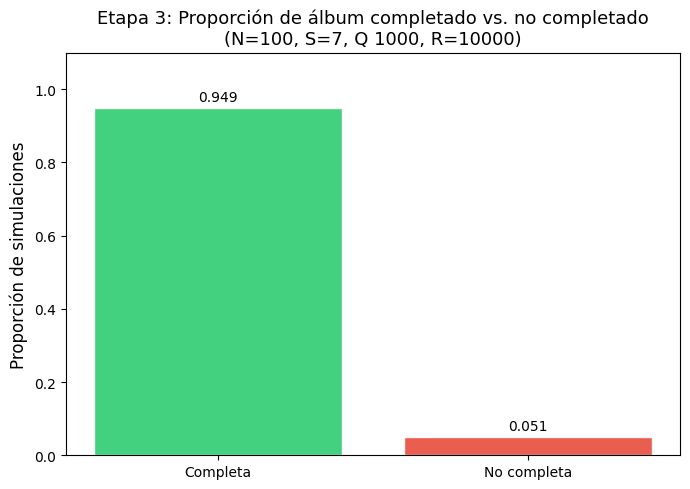

Gráfica guardada como 'etapa3_barras.png'


In [4]:
# ── Visualización Etapa 3: Éxito vs. no éxito ──
fig, ax = plt.subplots(figsize=(7, 5))

proporciones = [prob_completar, 1 - prob_completar]
etiquetas = ['Completa', 'No completa']
colores = ['#2ecc71', '#e74c3c']
bars = ax.bar(etiquetas, proporciones, color=colores, edgecolor='white', alpha=0.9)

for bar, p in zip(bars, proporciones):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Proporción de simulaciones', fontsize=12)
ax.set_title('Etapa 3: Proporción de álbum completado vs. no completado\n(N=100, S=7, Q 1000, R=10000)', fontsize=13)
plt.tight_layout()
plt.savefig('etapa3_barras.png', dpi=150)
plt.show()
print("Gráfica guardada como 'etapa3_barras.png'")

In [5]:
# Resumen comparativo: sobres sueltos vs caja
print('=== COMPARACIÓN: SOBRES SUELTOS vs CAJA (104 sobres) ===')
try:
    print(f'Probabilidad (sobres sueltos, Q1000): {prob_completar:.4f}')
    print(f'Probabilidad (caja 104, Q975):             {prob_caja:.4f}')
    print(f'Sobres máximos con Q1000:                 {max_sobres_presupuesto} (gasto Q{max_sobres_presupuesto * precio_sobre:.2f})')
    print(f'Mejor estrategia mixta encontrada:       {mejor_opcion[0]} caja(s) + {mejor_opcion[1]} sobre(s) = {mejor_opcion[2]} sobres')
    if prob_completar > prob_caja:
        print('Conclusión: Comprar sobres sueltos (usar el presupuesto) da una probabilidad ligeramente mayor.')
    elif prob_completar < prob_caja:
        print('Conclusión: Comprar la caja de 104 sobres da una probabilidad ligeramente mayor.')
    else:
        print('Conclusión: Probabilidades indistinguibles entre caja y sobres sueltos.')
except NameError:
    print('Variables de la simulación no están definidas en el kernel. Ejecute la celda de Etapa 3 primero.')

=== COMPARACIÓN: SOBRES SUELTOS vs CAJA (104 sobres) ===
Probabilidad (sobres sueltos, Q1000): 0.9488
Probabilidad (caja 104, Q975):             0.9468
Sobres máximos con Q1000:                 105 (gasto Q997.50)
Mejor estrategia mixta encontrada:       1 caja(s) + 2 sobre(s) = 106 sobres
Conclusión: Comprar sobres sueltos (usar el presupuesto) da una probabilidad ligeramente mayor.


---
## Resumen final

| Resultado | Valor |
|---|---|
| E[T] teórico (N=100, S=7) | ver celda arriba |
| E[T] simulado | ver celda arriba |
| M para P ≥ 50% | ver Etapa 2 |
| M para P ≥ 90% | ver Etapa 2 |
| P(completar) con Q 1000 | ver Etapa 3 |
| Sobres máximos con Q 1000 | 105 |
| P(completar) con caja de 104 sobres | ver Etapa 3 |
| Mejor estrategia mixta | 1 caja + 2 sobres sueltos |